# Signaler och system  - Lab 2


## 1. Förberedelse
### Uppgift 1.1
Beräkna autokorrelationen $r_{xx} (l)$ för $x(n)=\cos(2π0.1n)$ 
För vilka $l$ antar $r_{xx} (l)$ sitt max?



Svar: r_xx(l) = 1/2 cos(2pi * 0.1 * l) och antar sitt maxvärde då l = 10k, k är heltal

### Uppgift 1.2
Beräkna korskorrelationen $r_{xy} (l)$ mellan $x(n)=[1 2 1 0 0 0 0 0 0 ]$ och $y(n)=[1 2 1 0 0 0 1 2 1 ]$
För vilka $l$ antar $r_{xy} (l)$ sitt max?


Svar: Man kan alternativt beräkna det med formeln för korskorrelation (lite struligt) eller rita upp det och flytta för hand och räkna ihop. I vilket fall som helst så blir det maximalt för l = 0 och l = 6.


### Uppgift 1.3
Se till att paketen som behövs är installerad genom att köra koden nedan.

In [19]:
%pip install -q numpy
%pip install -q scipy
%pip install -q matplotlib
%pip install -q pyqt6

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Importera de bibliotek som behövs för Lab 2

In [20]:
import numpy as np
import scipy.io

#För interaktiva plottar i separat fönster (med zoom och pan)
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Autokorrelation
Autokorrelation kan användas för att skatta periodicitet i signaler. Här är ett enkelt exempel som illustrerar detta.

### Uppgift 2.1 
Skapa cosinussignal $x$ av längd $N=100$ med normerad frekvens $f=0.1$. Beräkna och plotta dess autokorrelation $r$. För vilka fördröjningar $l$ har autokorrelationsfunktionen $r$ toppar?

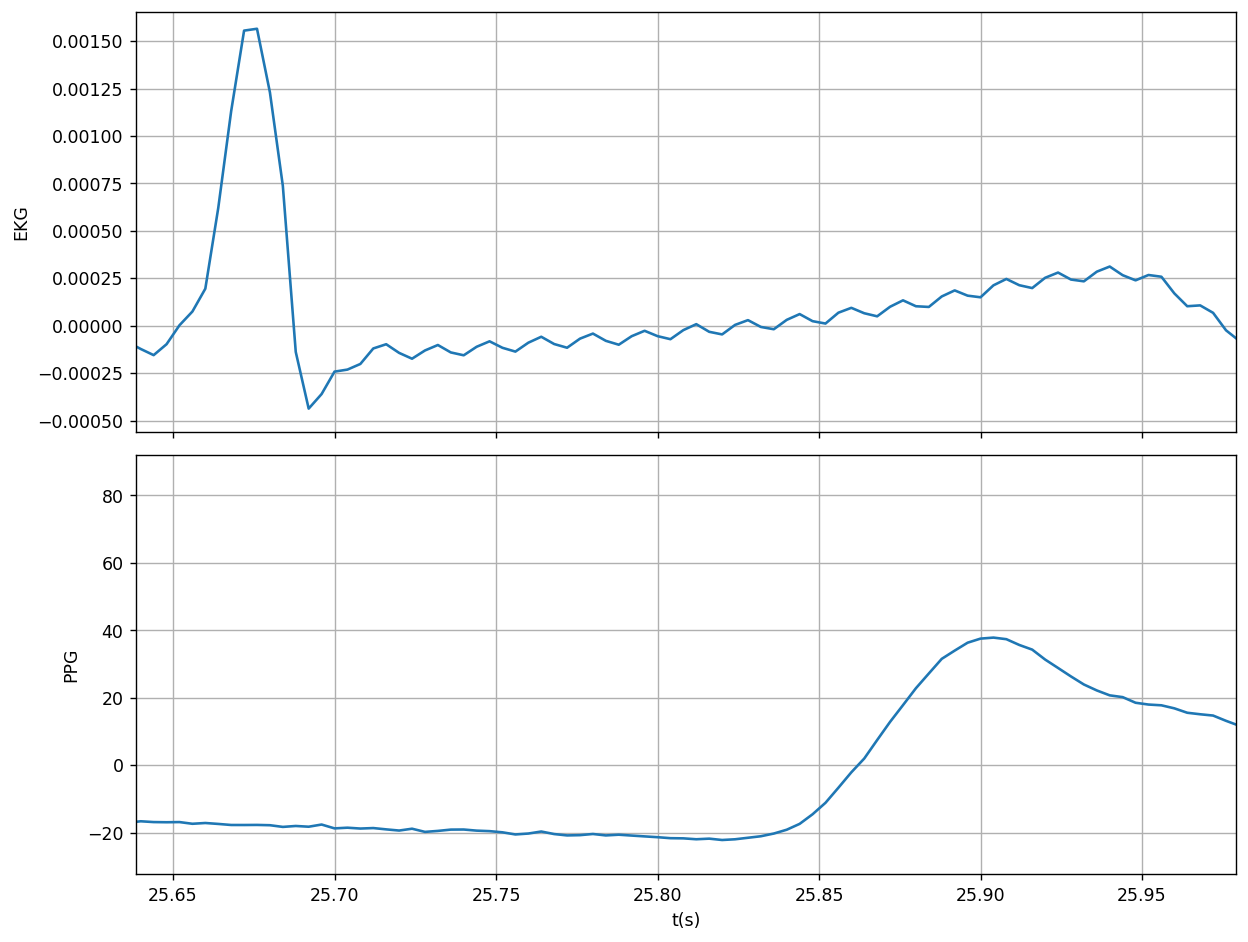

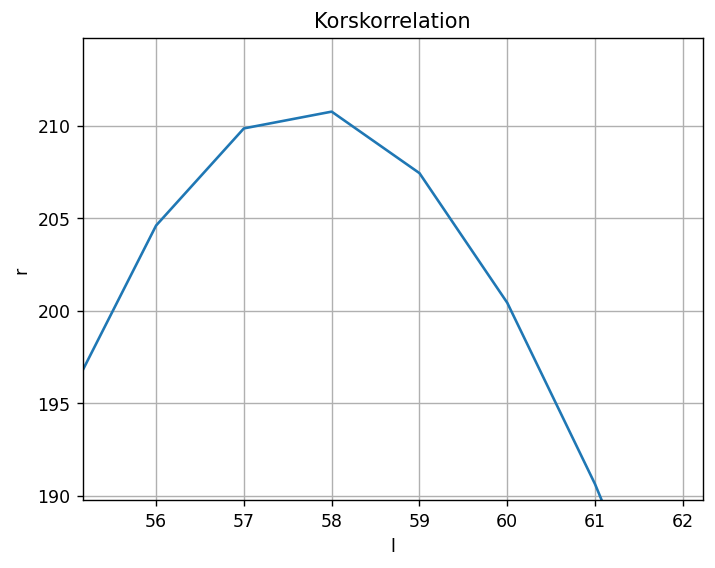

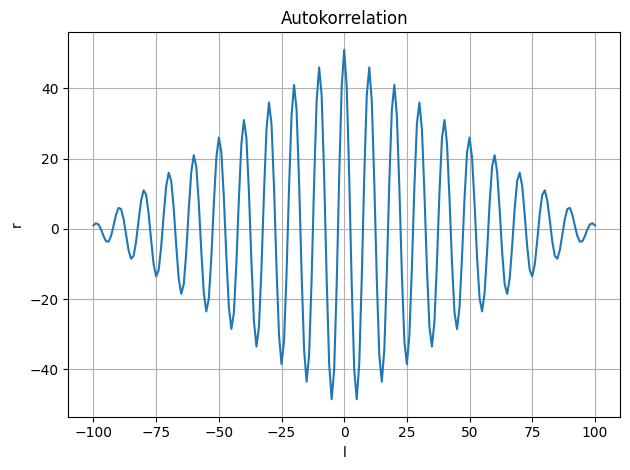

In [21]:
N = 100  
f = 0.1    

# Skapa vektor med sampel index från 0 till N
n = np.arange(0, N + 1)

# Skapa cosinussignal
x = np.cos(2 * np.pi * f * n) 


# Beräkna autokorrelation
r = np.correlate(x, x, mode='full')
l = np.arange(-len(x) + 1, len(x))  # Skapa lag vektor

# Plotta
plt.figure()
plt.plot(l, r)
plt.xlabel('l')
plt.ylabel('r')
plt.title('Autokorrelation')
plt.grid()

plt.tight_layout()
plt.show()

# Autokorrelationsfunktionen r har maximum för l = 10k där k är heltal, precis som i förberedelseuppgifterna! 
# Om man kollar så ser vi att det faktistk är exakt samma som i förberedelseuppgifterna.

### Uppgift 2.2

Skapa en cosinussignal $x2$ med normerad frekvens $f2=0.2$. Beräkna och plotta dess autokorrelation $r$.
För vilka fördröjningar $l$ har autokorrelationsfunktionen toppar?

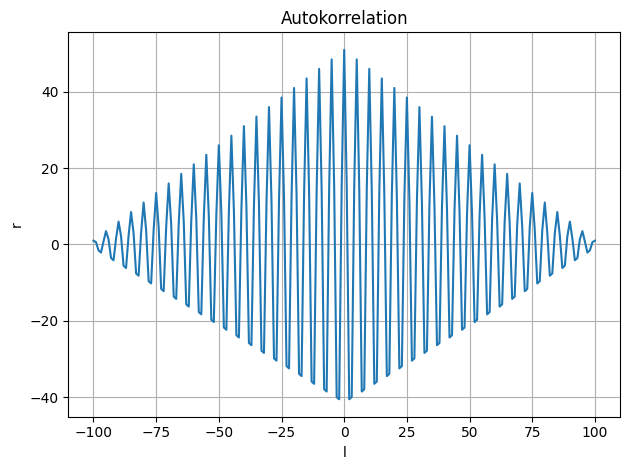

In [22]:
N = 100  
f = 0.2    

# Skapa vektor med sampel index från 0 till N
n = np.arange(0, N + 1)

# Skapa cosinussignal
x = np.cos(2 * np.pi * f * n) 


# Beräkna autokorrelation
r = np.correlate(x, x, mode='full')
l = np.arange(-len(x) + 1, len(x))  # Skapa lag vektor

# Plotta
plt.figure()
plt.plot(l, r)
plt.xlabel('l')
plt.ylabel('r')
plt.title('Autokorrelation')
plt.grid()

plt.tight_layout()
plt.show()

# Det är samma kod som föregående fast vi då har ändrat den normerade frekvensen och får därför en högre frekvens med maximal l = 5k där k är heltal.



### Uppgift 2.3
Testa även att beräkna autokorrelationen för cosinus signaler med andra frekvenser. Vilken relation finns mellan placeringen av autokorrelationsfunktionens toppar och frekvensen hos cosinus signalen?

In [23]:
# Om vi vill hitta ett exakt förhållande mellan placeringen av autokorrelationsfunktionens toppar och frekvensen så får vi följande:
#l = k * T = k * 1/f
# där k är heltal och T är period och f frekvens. Exempelvis l = k * 1/0.1 = 10k.

## 3. Korskorrelation
Korskorrelation kan användas för att skatta tidsfördröjningen mellan signaler. Här är ett enkelt exempel som illustrerar detta.
### Uppgift 3.1
Skapa en signal $x_1$ och en annan signal $x_2$ som är $x_1$ fördröjd $d=10$ sampel och plotta de båda signalerna. 

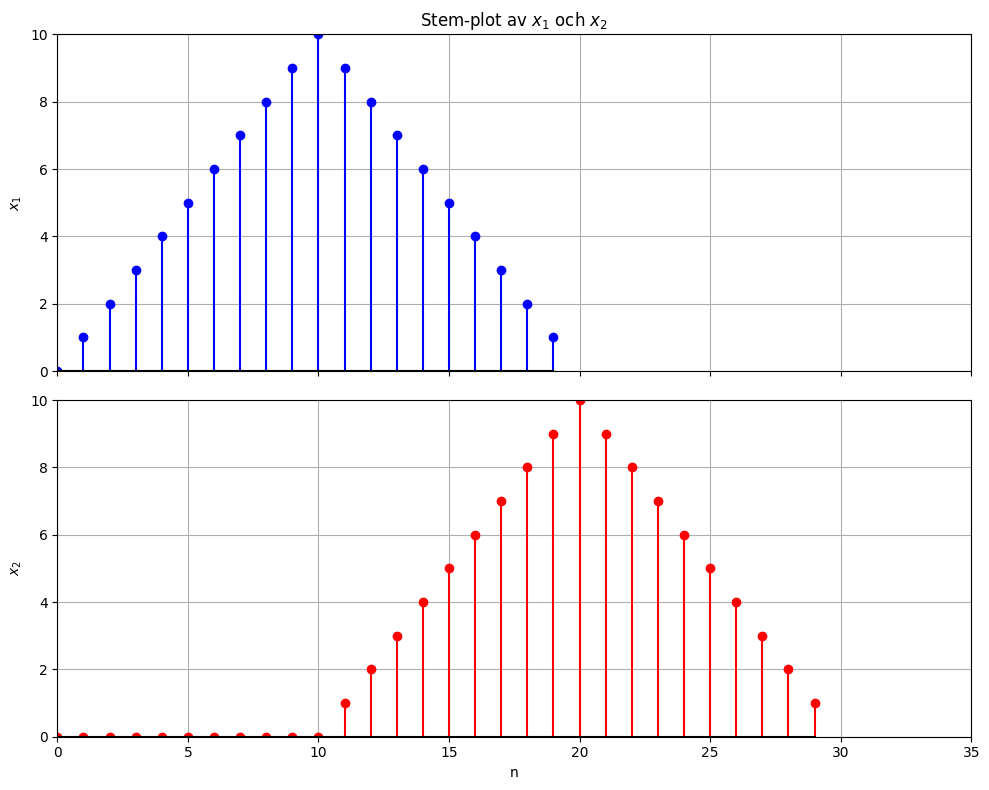

In [24]:
# Skapa x1: [0,1,2,...,10,10,9,...,1]
x1 = np.concatenate((np.arange(0, 10), np.arange(10, 0, -1)))

# Skapa x2 med förskjutning d
d = 10  
x2 = np.concatenate((np.zeros(d), x1))

# Skapa figur med 2 subplots som delar x-axel
fig, (ax1, ax2,) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Plotta x1
ax1.stem(x1, linefmt='b-', markerfmt='bo', basefmt='k-')
ax1.axis([0, 35, 0, 10])
ax1.set_ylabel('$x_1$')
ax1.set_title('Stem-plot av $x_1$ och $x_2$')
ax1.grid()

# Plotta x2
ax2.stem(x2, linefmt='r-', markerfmt='ro', basefmt='k-')
ax2.axis([0, 35, 0, 10])
ax2.set_ylabel('$x_2$')
ax2.set_xlabel('n')
ax2.grid()

plt.tight_layout()
plt.show()

### Uppgift 3.2 
Beräkna och plotta korskorrelationen mellan $x_2$ och $x_1$.
För vilket $l$ är korskorrelationen maximal?

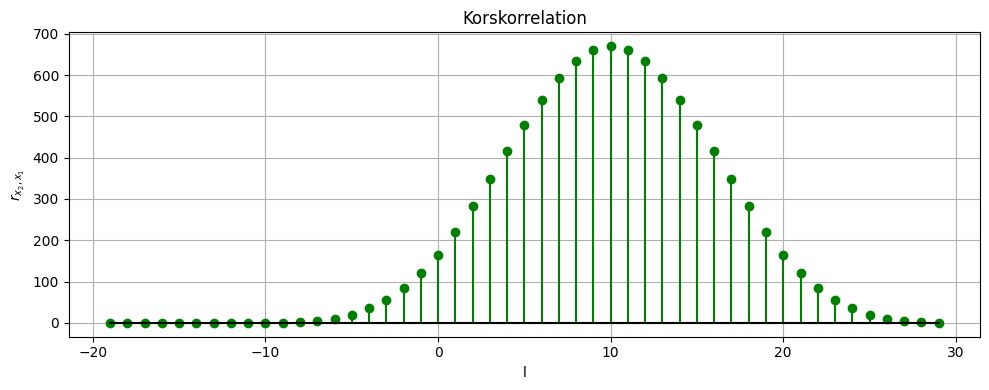

In [25]:
# Beräkna korskorrelation mellan x2 och x1
r = np.correlate(x2, x1, mode='full')
l = np.arange(-len(x1)+1, len(x2))

# Plot korskorrelation
plt.figure(figsize=(10, 4))
plt.stem(l, r, linefmt='g-', markerfmt='go', basefmt='k-')
plt.xlabel('l')
plt.ylabel('$r_{x_2,x_1}$')
plt.title('Korskorrelation')
plt.grid()

plt.tight_layout()
plt.show()

# Vi visste ju att vi skapade de två signalerna med en förskjutning på 10, så det är inte så konstigt att korskorrelationen har ett maximum vid l = 10. 
# Det är ju där de två signalerna är som mest lika varandra.

### Uppgift 3.3
Gör om samma sak som i uppgift 3.1 och 3.2, men ändra fördröjningen genom att sätta d=5. 
För vilket l är korskorrelationen nu maximal?

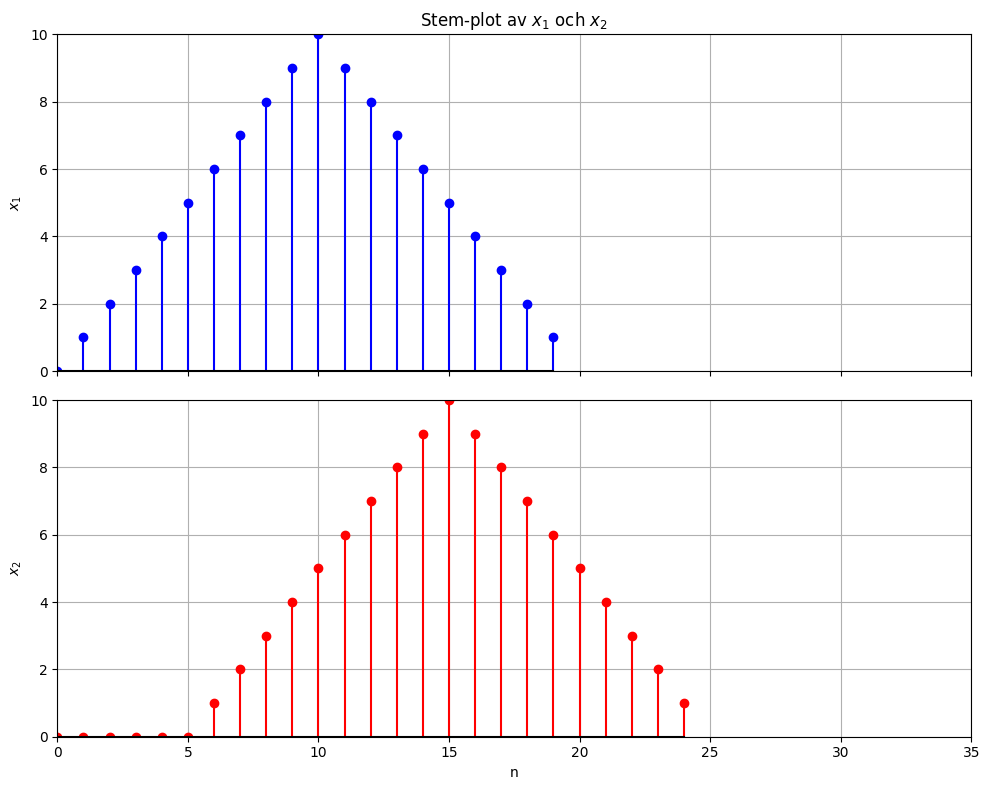

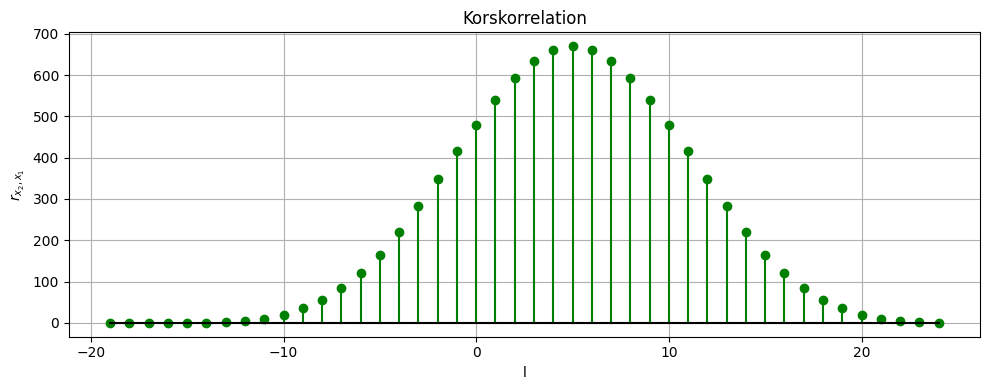

In [26]:
# Skapa x2 med förskjutning d
d = 5 
x2 = np.concatenate((np.zeros(d), x1))

# Skapa figur med 2 subplots som delar x-axel
fig, (ax1, ax2,) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plotta x1
ax1.stem(x1, linefmt='b-', markerfmt='bo', basefmt='k-')
ax1.axis([0, 35, 0, 10])
ax1.set_ylabel('$x_1$')
ax1.set_title('Stem-plot av $x_1$ och $x_2$')
ax1.grid()

# Plotta x2
ax2.stem(x2, linefmt='r-', markerfmt='ro', basefmt='k-')
ax2.axis([0, 35, 0, 10])
ax2.set_ylabel('$x_2$')
ax2.set_xlabel('n')
ax2.grid()

plt.tight_layout()
plt.show()

# Beräkna korskorrelation mellan x2 och x1
r = np.correlate(x2, x1, mode='full')
l = np.arange(-len(x1)+1, len(x2))

# Plot korskorrelation
plt.figure(figsize=(10, 4))
plt.stem(l, r, linefmt='g-', markerfmt='go', basefmt='k-')
plt.xlabel('l')
plt.ylabel('$r_{x_2,x_1}$')
plt.title('Korskorrelation')
plt.grid()

plt.tight_layout()
plt.show()


### Uppgift 3.4 
Beräkna istället korskorrelationen mellan x1 och x2. 
För vilka l är korskorrelationen maximal?

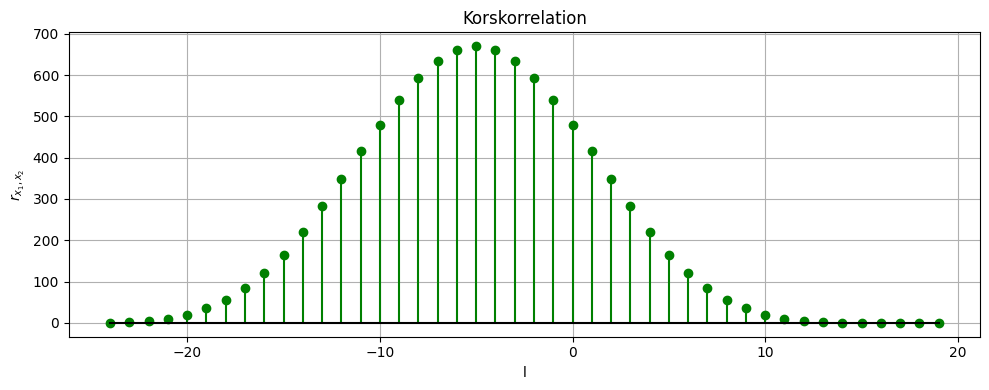

In [27]:
# Beräkna korskorrelation mellan x1 och x2
r = np.correlate(x1, x2, mode='full')
l = np.arange(-len(x2)+1, len(x1))

# Plot korskorrelation
plt.figure(figsize=(10, 4))
plt.stem(l, r, linefmt='g-', markerfmt='go', basefmt='k-')
plt.xlabel('l')
plt.ylabel('$r_{x_1,x_2}$')
plt.title('Korskorrelation')
plt.grid()

plt.tight_layout()
plt.show()

# Vi ser alltså här att om vi byter ordning på signalerna så byter vi också tecknet på l där korskorrelationen har sitt maximum. 
# Det är ju inte så konstigt eftersom det är där de två signalerna är som mest lika varandra

## 4. EKG och PPG
### Uppgift 4.1
Filen *ppg_ecg.npz* består av samtidigt inspelade 1-kanals elektrokardiografi (EKG) och finger fotopletysmografi (PPG) signaler från en försöksperson. I EKG mäts elektriska potentialskillnader över hjärtat med elektroder kroppsytan. Potentialskillnaderna varierar över tiden eftersom hjärtats kontraktion styrs av elektriska impulser. I PPG mäts intensiteten hos ljus som reflekteras från hudytan och de därunder belägna röda blodkropparna används för att bestämma blodvolymen i mätområdet.  Denna blodvolym varierar över tiden med det pulserande blodet. Signalerna är samplade med frekvens Fs = 250 Hz.

Läs in filen och plotta EKG och PPG signalerna som funktion av tid. 
Hur lång är inspelningen? Vilken hjärtfrekvens har testpersonen?

In [28]:
%matplotlib qt
data = np.load("ppg_ecg.npz")

# Skriv ut alla variabelnamn
print("Variabler i filen:", list(data.keys()))

ekg = data['ekg']
print("EKG storlek:", ekg.shape)

ppg = data['ppg']
print("PPG storlek:", ekg.shape)

# Definiera samplings frekvens (Fs)
Fs = 250 

# Skapa tidsvektor
t = np.arange(0, ekg.shape[1] / Fs, 1 / Fs)

# Skapa figur med 2 subplots som delar x-axel
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plotta ekg
ax1.plot(t,ekg[0,:])
ax1.set_ylabel('EKG')
ax1.grid()

# Plotta ppg
ax2.plot(t,ppg[0,:])
ax2.set_ylabel('PPG')
ax2.set_xlabel('t(s)');
ax2.grid()

plt.tight_layout()
plt.show()


# Precis som i labb1 så kan vi beräkna pulsen genom att räkna antalet toppar i ett intervall och sedan multiplicera det med 60 för att få pulsen i bpm.
# Ett 10 sekunders-intervall ger 12 slag vilket motsvarar 1.2 Hz eller 72 bpm. Det är ju en normal puls så det verkar rimligt!
# Inspelningen är 490 sekunder lång eller drygt 8 minuter.

Variabler i filen: ['ekg', 'ppg']
EKG storlek: (1, 122760)
PPG storlek: (1, 122760)


### Uppgift 4.2 

Att skatta hjärtfrekvensen genom att avläsa tiden mellan enskilda pulser i EKG eller PPG signalen är inte speciellt tillförlitligt eftersom tiden mellan varje hjärtslag inte är exakt lika lång. Sådan hjärtfrekvensvariabilitet är helt normal och beror på autonoma nervsystemets reglering. Hjärtat hos en ung frisk individ slår t.ex. något fortare under inandning än under utandning (respiratoriska sinusarytmi). Ett mer robust alternativ är att avläsa tiden mellan flera pulser och beräkna medelvärdet. För att skatta hjärtfrekvensen i en lång inspelning krävs i så fall automatiserad pulsdetektering. Ett enklare alternativ för att skatta medelhjärtfrekvensen är att använda autokorrelation.

Beräkna och plotta autokorrelation för EKG signalen.
För vilka l har autokorrelationsfunktionen toppar? 
Hur relaterar detta till tiden mellan pulserna i EKG signalen?

In [29]:
# Beräkna autokorrelation
r = np.correlate(ekg[0,:], ekg[0,:], mode='full')
l = np.arange(-ekg.shape[1] + 1, ekg.shape[1])  # Skapa lag vektor

# Plotta
plt.figure()
plt.plot(l, r)
plt.xlabel('l')
plt.ylabel('r')
plt.title('Autokorrelation')
plt.grid()


# Vi beräknar autokorrelationen enligt oven och vi ser att det finns toppar i autokorrelationsfunktionen som är ungefär 240 sampel ifrån varandra.

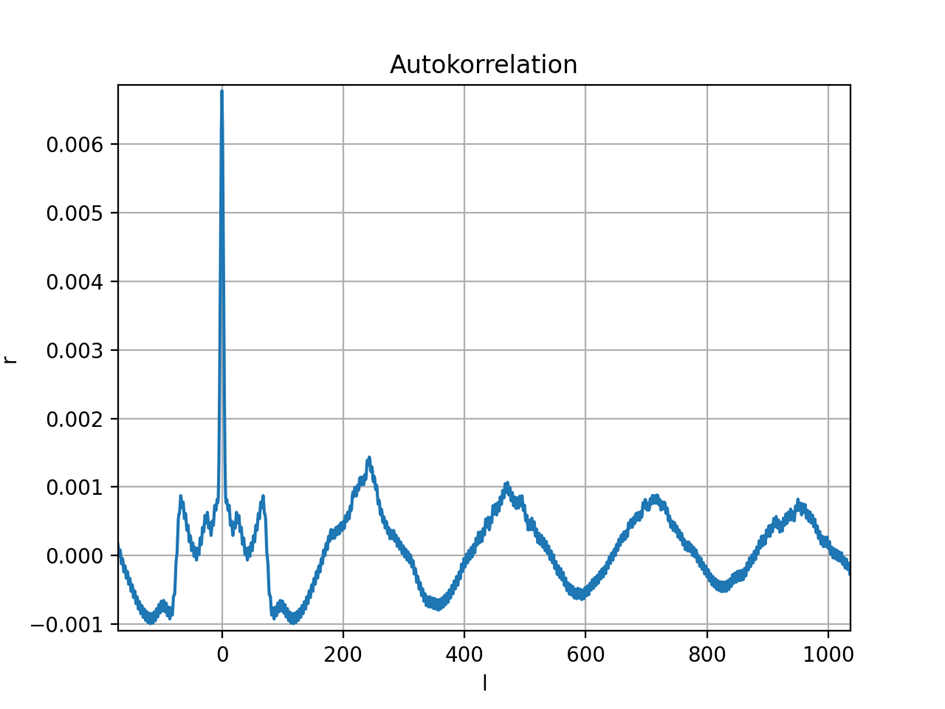

### Uppgift 4.3 
Beräkna och plotta autokorrelation för PPG signalen. För vilka l har autokorrelationsfunktionen toppar? Hur relaterar detta till tiden mellan pulserna i PPG signalen?

In [30]:
# Beräkna autokorrelation
r = np.correlate(ppg[0,:], ppg[0,:], mode='full')
l = np.arange(-ppg.shape[1] + 1, ppg.shape[1])  # Skapa lag vektor

# Plotta
plt.figure()
plt.plot(l, r)
plt.xlabel('l')
plt.ylabel('r')
plt.title('Autokorrelation')
plt.grid()

# Vi ser även här att vi har toppar vid varje 240 sampel, alltså k*240. Perioden på 240 samepel motsvarar periodtid på 0.96 sekunder (då sampelfrekvensen är 250 Hz) vilket ger 62.5 bpm.)


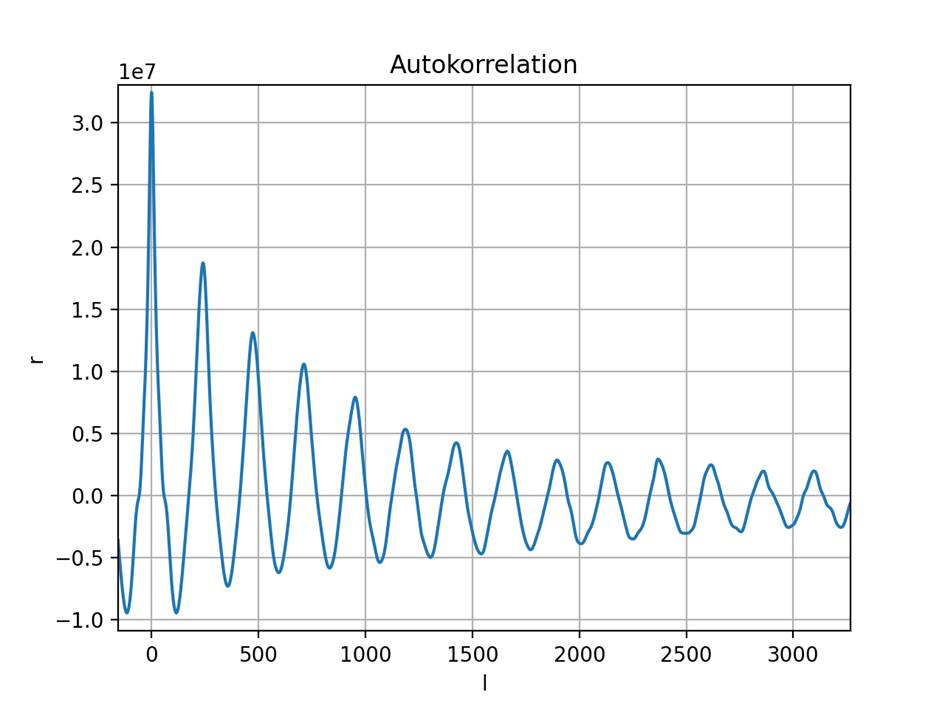

### Uppgift 4.4 
Det finns en tidsfördröjning mellan den elektriska aktiveringen av hjärtat som syns i EKG signalen och ändringen av blodvolym i fingertoppen som syns i PPG signalen. Denna tidsfördröjning kallas pulse transit time (PTT) och påverkas bland annat av blodkärlens styvhet. 

Plotta EKG och PPG signalen och zooma in några hjärtslag.
Hur många sampels fördröjning är det mellan EKG pulsen och PPG pulsen? 
Vilken PTT motsvarar detta? 

In [31]:
# Skapa tidsvektor
t = np.arange(0, ekg.shape[1] / Fs, 1 / Fs)

# Skapa figur med 2 subplots som delar x-axel
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plotta ekg
ax1.plot(t,ekg[0,:])
ax1.set_ylabel('EKG')
ax1.grid()

# Plotta ppg
ax2.plot(t,ppg[0,:])
ax2.set_ylabel('PPG')
ax2.set_xlabel('t(s)');
ax2.grid()

plt.tight_layout()
plt.show()

# Fördröjningen i tid mellan EKG och PPG är ungefär 0.23 sekunder, eller 230ms vilket motsvarar ungefär 57 sampel. 


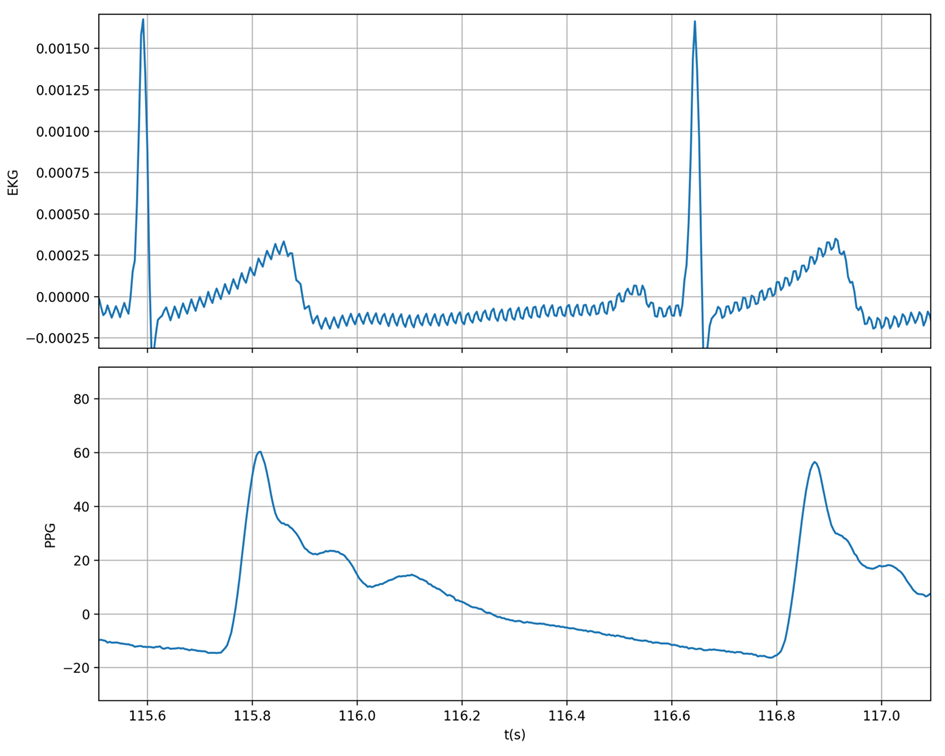

### Uppgift 4.5
Ett annat sätt att skatta fördröjningen mellan PPG och EKG, som inte kräver pulsdetektering, är att använda korskorrelation. Gör detta!
Hur lång är PTT skattad med korskorrelation? 

In [32]:
# Beräkna korskorrelation
r = np.correlate(ppg[0,:], ekg[0,:], mode='full')
l = np.arange(-ppg.shape[1] + 1, ppg.shape[1])  # Skapa lag vektor

# Plotta
plt.figure()
plt.plot(l, r)
plt.xlabel('l')
plt.ylabel('r')
plt.title('Korskorrelation')
plt.grid()

# Avläst från korskorelationen så ser vi att det finns ett maximum vid 58 sampel, vilket motsvarar 0.232 sekunder. Det är ju ungefär det vi avläste från tidsdomänen så det verkar rimligt!


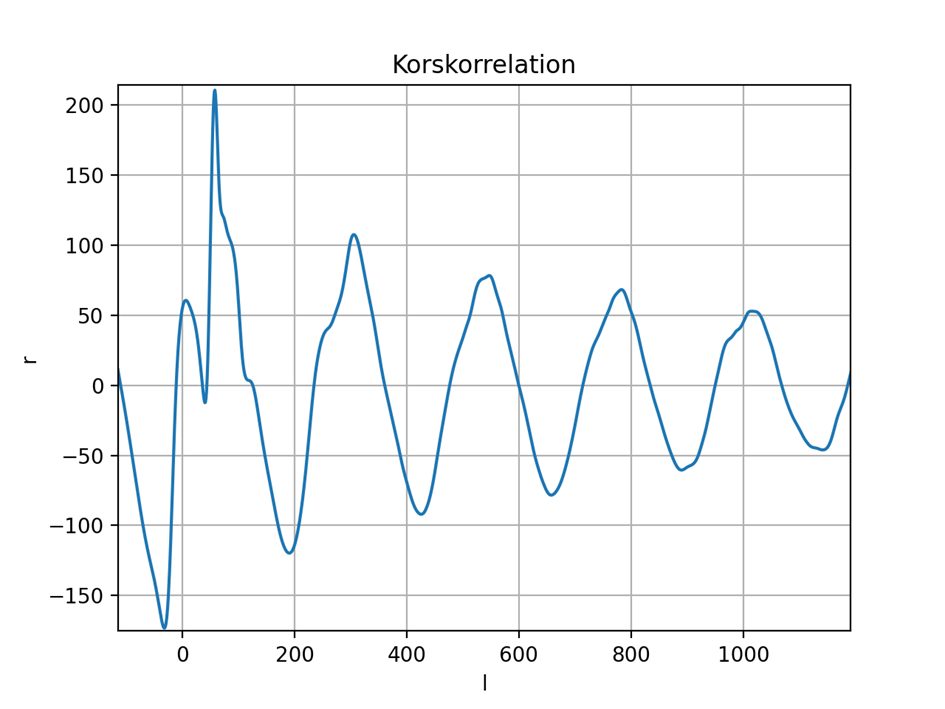